<a href="https://colab.research.google.com/github/ianelgar40/IansMIS433/blob/main/mis_433_competition_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8')
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')





In [11]:
# Colab only: mount Google Drive and set output folder for submissions
from google.colab import drive

drive.mount('/content/drive')

output_dir = '/content/drive/My Drive/Colab Notebooks/output/'
os.makedirs(output_dir, exist_ok=True)
print(f'Submission files will be saved to: {output_dir}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Submission files will be saved to: /content/drive/My Drive/Colab Notebooks/output/


In [12]:
accounts= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data /accounts.csv')

accounts.head()

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


In [13]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data /churn_train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data /churn_test.csv')



In [14]:
accounts.shape

(5298, 8)

In [15]:
train.shape

(4238, 2)

In [16]:
train

,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0
...,...,...
4233,6492,0
4234,6493,0
4235,6494,0
4236,6497,0


In [17]:
accounts.isnull().sum()

,0
CustomerNo,0
BaseCharges,0
DOC,0
TotalCharges,10
DOE,0
ElectronicBilling,0
ContractType,5
PaymentMethod,0


In [18]:
accounts.duplicated().sum()

np.int64(0)

In [19]:
test

,CustomerNo
0,1203
1,1204
2,1208
3,1220
4,1221
...,...
1055,6478
1056,6486
1057,6487
1058,6495


In [20]:
df_train = pd.merge(train, accounts, on='CustomerNo')
df_train

,CustomerNo,Churn,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,0,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,0,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1205,1,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check
3,1206,0,99.50,5-1-2012,6775.50,7-Mar-06,Yes,Two year,Credit card (automatic)
4,1207,0,91.25,5-1-2012,2673.50,17-Sep-09,No,One year,Credit card (automatic)
...,...,...,...,...,...,...,...,...,...
4233,6492,0,100.00,5-1-2012,6980.00,5-Jun-06,Yes,Two year,Credit card (automatic)
4234,6493,0,227.75,5-1-2012,10541.75,26-Jan-08,No,Month-to-month,Credit card (automatic)
4235,6494,0,99.50,5-1-2012,5113.00,27-Dec-07,Yes,Two year,Credit card (automatic)
4236,6497,0,426.00,5-1-2012,14372.25,21-Mar-09,Yes,Month-to-month,Credit card (automatic)


In [21]:
df_train[['Churn', 'BaseCharges']]

,Churn,BaseCharges
0,0,478.50
1,0,103.25
2,1,372.50
3,0,99.50
4,0,91.25
...,...,...
4233,0,100.00
4234,0,227.75
4235,0,99.50
4236,0,426.00


In [22]:
df_train.drop(['DOC', 'DOE', 'CustomerNo'], axis=1, inplace=True)

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Churn              4238 non-null   int64  
 1   BaseCharges        4238 non-null   float64
 2   TotalCharges       4230 non-null   float64
 3   ElectronicBilling  4238 non-null   object 
 4   ContractType       4235 non-null   object 
 5   PaymentMethod      4238 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 198.8+ KB


array([[<Axes: title={'center': 'Churn'}>,
        <Axes: title={'center': 'BaseCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

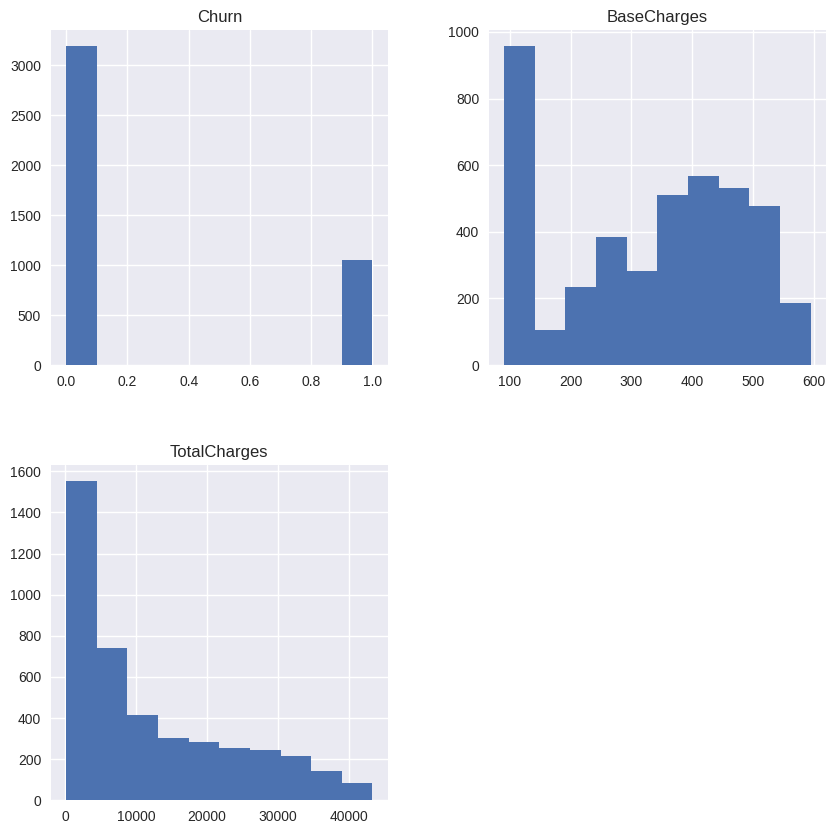

In [23]:
df_train.hist(figsize=(10,10))

<function matplotlib.pyplot.show(close=None, block=None)>

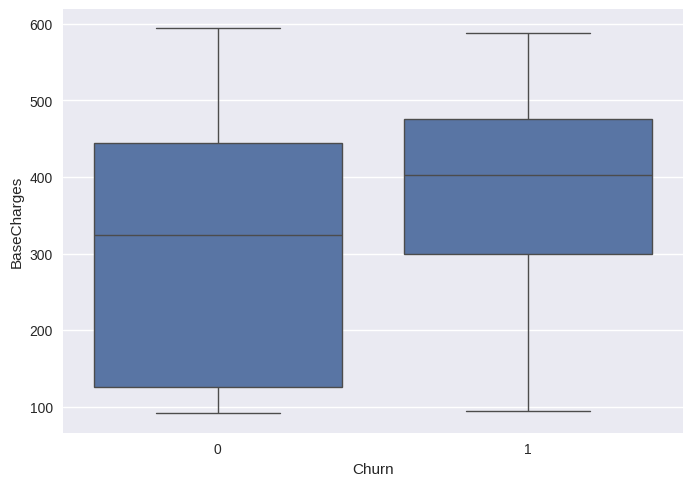

In [24]:
sns.boxplot(data=df_train, x='Churn', y='BaseCharges')
plt.show

<Axes: xlabel='Churn', ylabel='TotalCharges'>

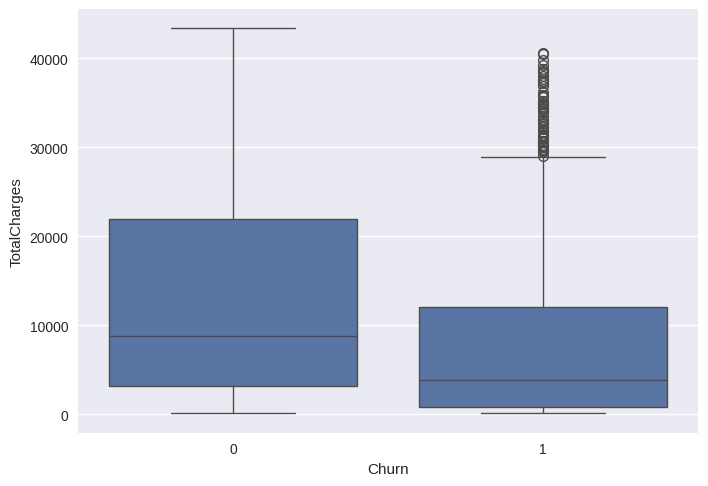

In [25]:
sns.boxplot(data=df_train, x='Churn', y='TotalCharges')


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder


x_pipeline=df_train.drop('Churn', axis=1)
y_pipeline=df_train['Churn']

num_cols= ['BaseCharges','TotalCharges']
cat_cols= ['ContractType']

num_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', MinMaxScaler())])
cat_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipline, num_cols),
        ('cat', OneHotEncoder(), cat_cols)])

tree_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(criterion='entropy', max_depth=6))
])

In [29]:
tree_pipline.fit(x_pipeline, y_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['BaseCharges',
                                                   'TotalCharges']),
                                                 ('cat', OneHotEncoder(),
                                                  ['ContractType'])])),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=6))])

In [30]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(tree_pipline, x_pipeline, y_pipeline, cv=100)
print(f"Cross-validation mean score: {score.mean():.4f}")

# Prepare the test data in the same way as the training data
df_test = pd.merge(test, accounts, on='CustomerNo')
df_test.drop(['DOC', 'DOE', 'CustomerNo','PaymentMethod', 'ElectronicBilling'], axis=1, inplace=True)

y_hat = tree_pipline.predict(df_test)

print(f"Shape of predictions: {y_hat.shape}")

Cross-validation mean score: 0.7796
Shape of predictions: (1060,)


In [31]:
score


array([0.79069767, 0.69767442, 0.65116279, 0.79069767, 0.86046512,
       0.76744186, 0.79069767, 0.74418605, 0.81395349, 0.76744186,
       0.72093023, 0.74418605, 0.74418605, 0.72093023, 0.81395349,
       0.76744186, 0.79069767, 0.74418605, 0.81395349, 0.81395349,
       0.8372093 , 0.8372093 , 0.74418605, 0.79069767, 0.69767442,
       0.76744186, 0.81395349, 0.79069767, 0.76744186, 0.8372093 ,
       0.76744186, 0.79069767, 0.79069767, 0.69767442, 0.8372093 ,
       0.86046512, 0.79069767, 0.79069767, 0.66666667, 0.71428571,
       0.83333333, 0.80952381, 0.80952381, 0.76190476, 0.73809524,
       0.73809524, 0.73809524, 0.76190476, 0.83333333, 0.73809524,
       0.76190476, 0.80952381, 0.78571429, 0.83333333, 0.71428571,
       0.73809524, 0.76190476, 0.76190476, 0.83333333, 0.78571429,
       0.80952381, 0.73809524, 0.80952381, 0.80952381, 0.83333333,
       0.85714286, 0.80952381, 0.61904762, 0.83333333, 0.80952381,
       0.78571429, 0.76190476, 0.88095238, 0.85714286, 0.78571

In [33]:
submission = pd.DataFrame({'CustomerNo': test['CustomerNo'], 'Churn': y_hat})

# Save the submission file to the output directory
submission_path = os.path.join(output_dir, 'submission.csv')
submission.to_csv(submission_path, index=False)

print(f"Submission file saved to: {submission_path}")

submission

Submission file saved to: /content/drive/My Drive/Colab Notebooks/output/submission.csv


,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0
...,...,...
1055,6478,0
1056,6486,0
1057,6487,0
1058,6495,0


Feature names used in the tree:
['BaseCharges', 'TotalCharges', 'ContractType_Month-to-month', 'ContractType_One year', 'ContractType_Two year', 'ContractType_nan']


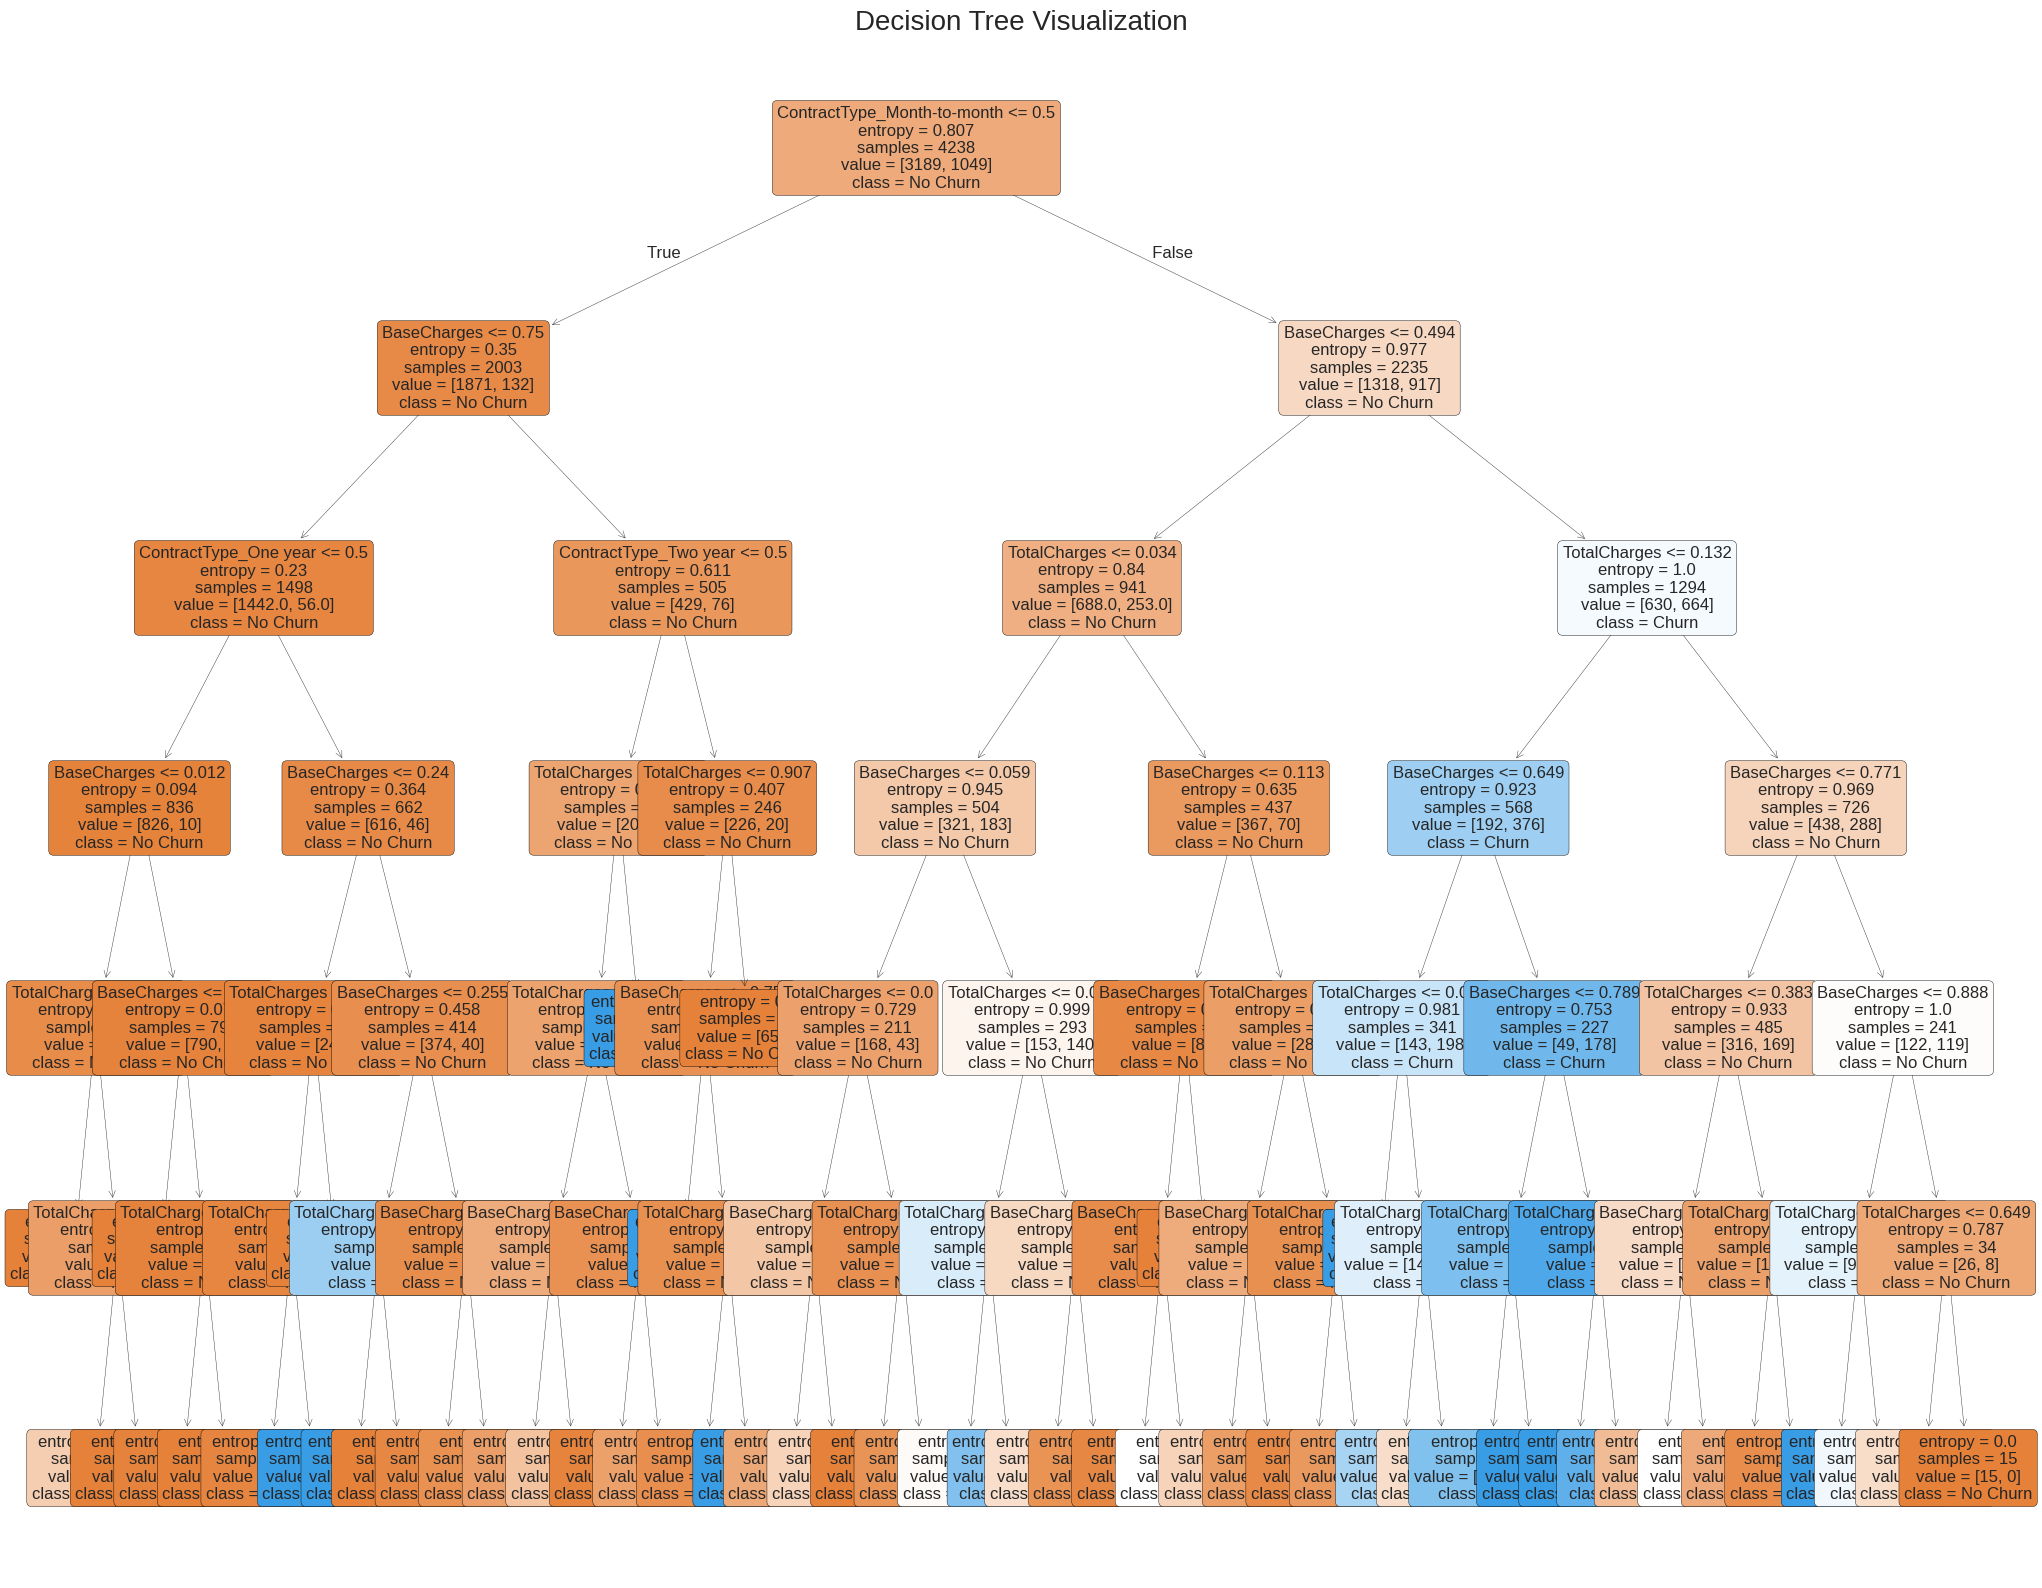

In [34]:
from sklearn.tree import plot_tree

# Extract the trained Decision Tree model from the pipeline
decision_tree_model = tree_pipline.named_steps['model']

# Get feature names after preprocessing
# The preprocessor contains the numerical and one-hot encoded categorical features
# We need to get the feature names from the preprocessor's ColumnTransformer

# Get the numerical feature names
numerical_feature_names = num_cols

# Get the one-hot encoded categorical feature names
onehot_encoder = tree_pipline.named_steps['preprocessor'].named_transformers_['cat']
categorical_feature_names = onehot_encoder.get_feature_names_out(cat_cols)

# Combine all feature names in the correct order
all_feature_names = numerical_feature_names + list(categorical_feature_names)

print("Feature names used in the tree:")
print(all_feature_names)

plt.figure(figsize=(25, 20))
plot_tree(decision_tree_model,
          feature_names=all_feature_names,
          class_names=['No Churn', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Decision Tree Visualization', fontsize=20)
plt.show()